In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import os
if os.path.exists("checkpoints/best_model.pth"):
    os.remove("checkpoints/best_model.pth")
    print("Old checkpoint deleted")
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
from PIL import Image as PILImage
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error

Old checkpoint deleted


1. BASIC INFO
Total rows    : 2982
Column names  : ['name', 'prompt', 'adj1', 'adj2', 'style', 'mos_quality', 'std_quality', 'mos_align', 'std_align']
                     name             prompt adj1 adj2 style  mos_quality  \
0  AttnGAN_normal_000.jpg    statue of a man  NaN  NaN   NaN     0.965603   
1  AttnGAN_normal_001.jpg    a tray of sushi  NaN  NaN   NaN     1.361853   
2  AttnGAN_normal_002.jpg  man lost in space  NaN  NaN   NaN     0.195283   

   std_quality  mos_align  std_align  
0     0.223270   0.408893   0.615608  
1     0.645422   0.428797   0.667071  
2     0.949403   0.506802   0.723514  

2. MISSING VALUES
⚠️  Missing values: {'adj1': 1190, 'adj2': 2188, 'style': 1587}

3. SCORE STATISTICS
mos_quality → min:0.000  max:4.489  mean:2.500  std:0.998
mos_align   → min:0.021  max:4.286  mean:2.500  std:0.999

Normalise quality? True → divide by 4.4887
Normalise align?   True   → divide by 4.2862
Use Sigmoid on model output? False

4. SCORE CORRELATION
Pearson correlatio

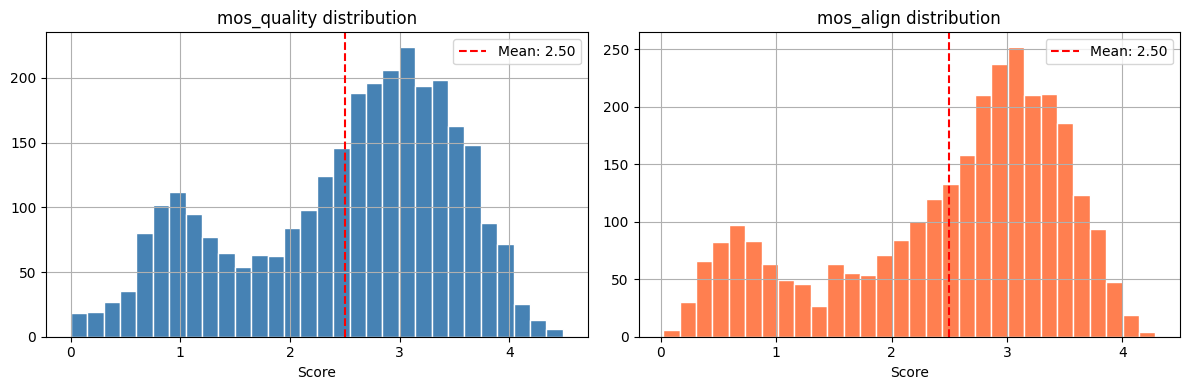

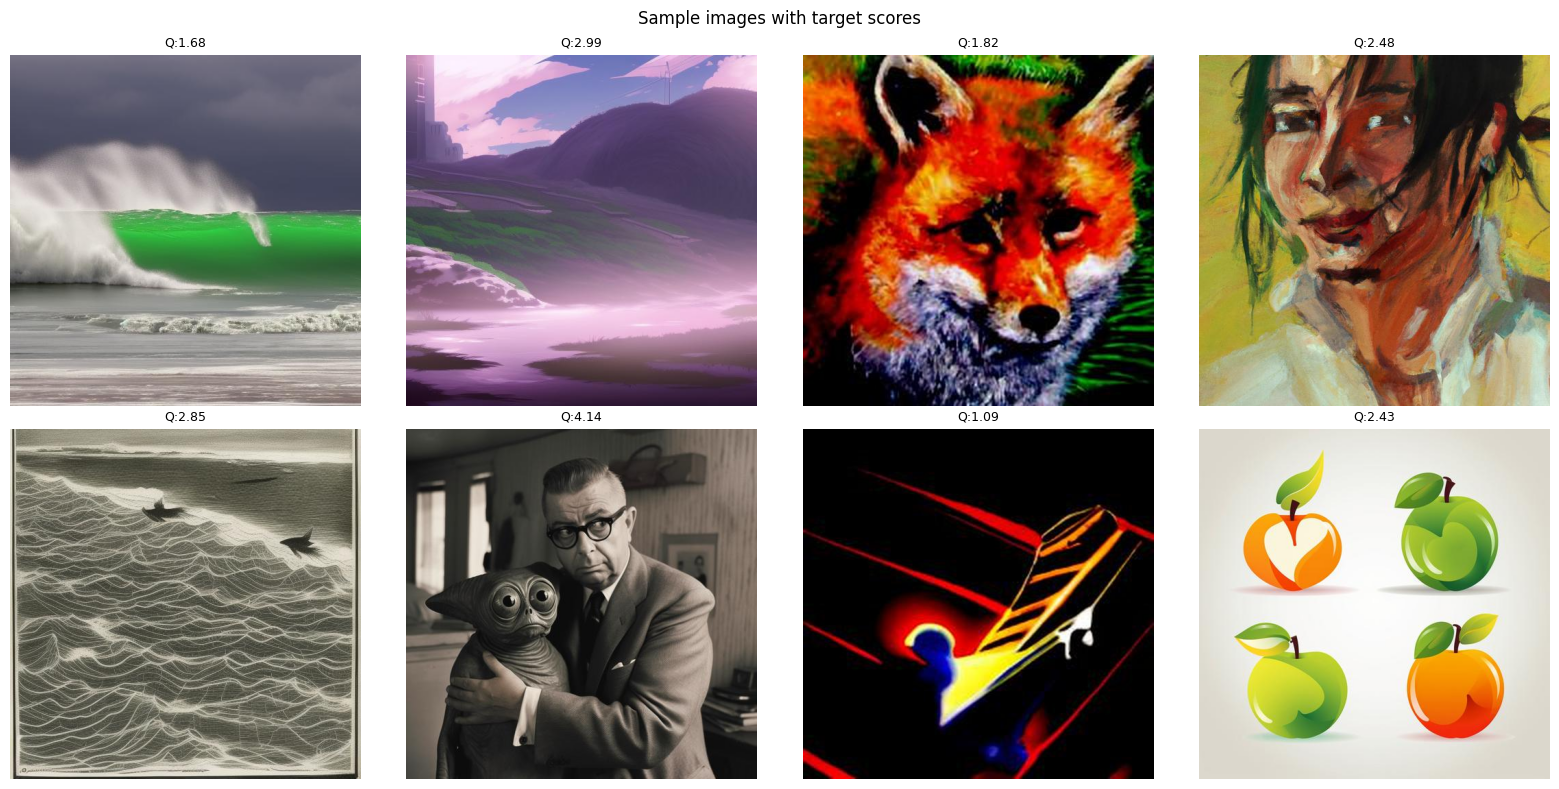


9. VARIABLES READY FOR ALL OTHER CELLS
  TRAIN_MODE       = 'quality_only'
  NUM_OUTPUTS      = 1
  TARGET_COLS      = ['mos_quality']
  NORM_FACTORS     = [np.float64(4.4887)]
  USE_SIGMOID      = False
  TOTAL_IMAGES     = 2982
  MISSING_IMAGES   = 0
  SCORE_CORRELATION= 0.8141
  Q_NORM_FACTOR    = 4.4887
  A_NORM_FACTOR    = 4.2862

✅ EDA complete — run remaining cells in order


In [2]:
# ── Config ───────────────────────────────────────────────────────────────────
CSV_PATH = "data/qual_ann.csv"
IMAGE_DIR = "data/images/"

df = pd.read_csv(CSV_PATH)

# ─────────────────────────────────────────────────────────────────────────────
# 1. BASIC INFO
# ─────────────────────────────────────────────────────────────────────────────
print("="*60)
print("1. BASIC INFO")
print("="*60)
TOTAL_IMAGES = len(df)
COL_NAMES = df.columns.tolist()
print(f"Total rows    : {TOTAL_IMAGES}")
print(f"Column names  : {COL_NAMES}")
print(df.head(3))

# ─────────────────────────────────────────────────────────────────────────────
# 2. MISSING VALUES
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("2. MISSING VALUES")
print("="*60)
missing = df.isnull().sum()
MISSING_COLS = missing[missing > 0].to_dict()
if not MISSING_COLS:
    print("✅ No missing values")
else:
    print(f"⚠️  Missing values: {MISSING_COLS}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. SCORE STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("3. SCORE STATISTICS")
print("="*60)

Q_MIN = df["mos_quality"].min()
Q_MAX = df["mos_quality"].max()
Q_MEAN = df["mos_quality"].mean()
Q_STD = df["mos_quality"].std()

A_MIN = df["mos_align"].min()
A_MAX = df["mos_align"].max()
A_MEAN = df["mos_align"].mean()
A_STD = df["mos_align"].std()

print(f"mos_quality → min:{Q_MIN:.3f}  max:{Q_MAX:.3f}  mean:{Q_MEAN:.3f}  std:{Q_STD:.3f}")
print(f"mos_align   → min:{A_MIN:.3f}  max:{A_MAX:.3f}  mean:{A_MEAN:.3f}  std:{A_STD:.3f}")

# Should we normalise? (if max > 1.0 then yes)
NORMALISE_QUALITY = Q_MAX > 1.0
NORMALISE_ALIGN = A_MAX > 1.0
Q_NORM_FACTOR = Q_MAX if NORMALISE_QUALITY else 1.0
A_NORM_FACTOR = A_MAX if NORMALISE_ALIGN   else 1.0

print(f"\nNormalise quality? {NORMALISE_QUALITY} → divide by {Q_NORM_FACTOR:.4f}")
print(f"Normalise align?   {NORMALISE_ALIGN}   → divide by {A_NORM_FACTOR:.4f}")

# Should we keep Sigmoid? Only if scores end up in [0,1]
USE_SIGMOID = (not NORMALISE_QUALITY)
print(f"Use Sigmoid on model output? {USE_SIGMOID}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. CORRELATION → decide how many outputs to train
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("4. SCORE CORRELATION")
print("="*60)

SCORE_CORRELATION = df["mos_quality"].corr(df["mos_align"])
print(f"Pearson correlation: {SCORE_CORRELATION:.4f}")

if abs(SCORE_CORRELATION) > 0.8:
    TRAIN_MODE = "quality_only"    # scores too similar, no benefit training both
    NUM_OUTPUTS = 1
    TARGET_COLS = ["mos_quality"]
    NORM_FACTORS = [Q_NORM_FACTOR]
    print("⚠️  High correlation → training quality only (1 output)")
elif abs(SCORE_CORRELATION) > 0.5:
    TRAIN_MODE = "joint"
    NUM_OUTPUTS = 2
    TARGET_COLS = ["mos_quality", "mos_align"]
    NORM_FACTORS = [Q_NORM_FACTOR, A_NORM_FACTOR]
    print("ℹ️  Moderate correlation → joint training (2 outputs)")
else:
    TRAIN_MODE = "joint"
    NUM_OUTPUTS = 2
    TARGET_COLS  = ["mos_quality", "mos_align"]
    NORM_FACTORS = [Q_NORM_FACTOR, A_NORM_FACTOR]
    print("✅ Low correlation → joint training beneficial (2 outputs)")

# ─────────────────────────────────────────────────────────────────────────────
# 5. IMAGE FILE CHECK
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("5. IMAGE FILE CHECK")
print("="*60)

MISSING_IMAGES = [n for n in df["name"] if not os.path.exists(os.path.join(IMAGE_DIR, n))]
if not MISSING_IMAGES:
    print(f"✅ All {TOTAL_IMAGES} images found")
else:
    print(f"❌ {len(MISSING_IMAGES)} images missing: {MISSING_IMAGES[:5]}")
    # Remove missing images from df so training doesn't crash
    df = df[~df["name"].isin(MISSING_IMAGES)].reset_index(drop=True)
    print(f"  Removed missing entries. New size: {len(df)}")

# ─────────────────────────────────────────────────────────────────────────────
# 6. IMAGE SIZE CHECK
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("6. IMAGE SIZE CHECK")
print("="*60)

sizes = []
for name in df["name"].iloc[:20]:
    try:
        img = PILImage.open(os.path.join(IMAGE_DIR, name))
        sizes.append(img.size)
    except:
        pass

UNIQUE_SIZES = list(set(sizes))
IMAGES_ARE_SAME_SIZE = len(UNIQUE_SIZES) == 1
NATIVE_IMAGE_SIZE = UNIQUE_SIZES[0] if IMAGES_ARE_SAME_SIZE else None

print(f"Sizes found (W×H): {UNIQUE_SIZES}")
if IMAGES_ARE_SAME_SIZE:
    print(f"✅ All images are {NATIVE_IMAGE_SIZE[0]}×{NATIVE_IMAGE_SIZE[1]}")
else:
    print("ℹ️  Mixed sizes — transforms will handle this")

# ─────────────────────────────────────────────────────────────────────────────
# 7. SCORE DISTRIBUTIONS PLOT
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["mos_quality"].hist(ax=axes[0], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(Q_MEAN, color="red", linestyle="--", label=f"Mean: {Q_MEAN:.2f}")
axes[0].set_title("mos_quality distribution")
axes[0].set_xlabel("Score"); axes[0].legend()

df["mos_align"].hist(ax=axes[1], bins=30, color="coral", edgecolor="white")
axes[1].axvline(A_MEAN, color="red", linestyle="--", label=f"Mean: {A_MEAN:.2f}")
axes[1].set_title("mos_align distribution")
axes[1].set_xlabel("Score"); axes[1].legend()
plt.tight_layout(); plt.savefig("eda_distributions.png"); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 8. SAMPLE IMAGES PLOT
# ─────────────────────────────────────────────────────────────────────────────
sample = df.sample(8, random_state=42)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    try:
        img = mpimg.imread(os.path.join(IMAGE_DIR, row["name"]))
        ax.imshow(img)
        scores_str = "  ".join([f"{c.split('_')[1][0].upper()}:{row[c]:.2f}" for c in TARGET_COLS])
        ax.set_title(scores_str, fontsize=9)
    except Exception as e:
        ax.set_title(f"Error", fontsize=7)
    ax.axis("off")
plt.suptitle("Sample images with target scores", fontsize=12)
plt.tight_layout(); plt.savefig("eda_samples.png"); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 9. SUMMARY OF ALL VARIABLES PASSED TO OTHER CELLS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("9. VARIABLES READY FOR ALL OTHER CELLS")
print("="*60)
print(f"  TRAIN_MODE       = '{TRAIN_MODE}'")
print(f"  NUM_OUTPUTS      = {NUM_OUTPUTS}")
print(f"  TARGET_COLS      = {TARGET_COLS}")
print(f"  NORM_FACTORS     = {[round(f,4) for f in NORM_FACTORS]}")
print(f"  USE_SIGMOID      = {USE_SIGMOID}")
print(f"  TOTAL_IMAGES     = {TOTAL_IMAGES}")
print(f"  MISSING_IMAGES   = {len(MISSING_IMAGES)}")
print(f"  SCORE_CORRELATION= {SCORE_CORRELATION:.4f}")
print(f"  Q_NORM_FACTOR    = {Q_NORM_FACTOR:.4f}")
print(f"  A_NORM_FACTOR    = {A_NORM_FACTOR:.4f}")
print("\n✅ EDA complete — run remaining cells in order")

In [3]:
class AGIQADataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["name"])
        image = PILImage.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # ← uses TARGET_COLS and NORM_FACTORS from EDA
        scores = torch.tensor(
            [row[col] / norm for col, norm in zip(TARGET_COLS, NORM_FACTORS)],
            dtype=torch.float32
        )
        return image, scores


def get_transforms(image_size=224):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    train_tf = transforms.Compose([
        transforms.Resize((image_size + 32, image_size + 32)),
        transforms.RandomCrop(image_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tf, val_tf


def get_dataloaders(image_size=224, batch_size=32, val_split=0.15,
                    test_split=0.15, seed=42):
    # ← uses df cleaned by EDA
    shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    n = len(shuffled)
    n_test = int(n * test_split)
    n_val = int(n * val_split)
    n_train = n - n_val - n_test

    train_df = shuffled.iloc[:n_train]
    val_df = shuffled.iloc[n_train : n_train + n_val]
    test_df = shuffled.iloc[n_train + n_val :]

    print(f"Split — Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

    train_tf, val_tf = get_transforms(image_size)
    train_loader = DataLoader(AGIQADataset(train_df, IMAGE_DIR, train_tf),
                              batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader = DataLoader(AGIQADataset(val_df,   IMAGE_DIR, val_tf),
                              batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(AGIQADataset(test_df,  IMAGE_DIR, val_tf),
                              batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader, test_df

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class IQACNNFromScratch(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(3, 32, pool=True),
            ConvBlock(32, 64, pool=True),
            ConvBlock(64, 128, pool=True),
            ConvBlock(128, 256, pool=True),
            ConvBlock(256, 512, pool=True),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)

        # ← NUM_OUTPUTS and USE_SIGMOID come from EDA
        head_layers = [
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(128, NUM_OUTPUTS),
        ]
        if USE_SIGMOID:
            head_layers.append(nn.Sigmoid())

        self.head = nn.Sequential(*head_layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.gap(self.encoder(x)))


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params    : {total:,}")
    print(f"Trainable params: {trainable:,}")
    print(f"Outputs         : {NUM_OUTPUTS}  ({TRAIN_MODE})")
    print(f"Sigmoid         : {USE_SIGMOID}")

In [5]:
CHECKPOINT = "checkpoints/best_model.pth"
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 80
LR = 5e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
os.makedirs("checkpoints", exist_ok=True)

train_loader, val_loader, test_loader, test_df = get_dataloaders(IMAGE_SIZE, BATCH_SIZE)

model = IQACNNFromScratch(dropout=0.4).to(DEVICE)

def combined_loss(preds, targets):
    mse_loss  = nn.MSELoss()(preds, targets)
    # Pearson correlation loss pushes model to preserve ranking/range
    vx = preds  - preds.mean()
    vy = targets - targets.mean()
    plcc_loss = 1 - (vx * vy).sum() / (torch.sqrt((vx**2).sum()) * torch.sqrt((vy**2).sum()) + 1e-8)
    return mse_loss + 0.3 * plcc_loss

criterion = combined_loss
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

count_parameters(model)

Device: cuda
Split — Train: 2088  Val: 447  Test: 447
Total params    : 1,733,921
Trainable params: 1,733,921
Outputs         : 1  (quality_only)
Sigmoid         : False


In [6]:

from PIL import Image as PILImage

history = {"train_loss": [], "val_loss": [], "val_rmse": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for images, scores in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        images, scores = images.to(DEVICE), scores.to(DEVICE)
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, scores)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses, val_rmses = [], []
    with torch.no_grad():
        for images, scores in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]  "):
            images, scores = images.to(DEVICE), scores.to(DEVICE)
            preds = model(images)
            val_losses.append(criterion(preds, scores).item())
            val_rmses.append(torch.abs(preds - scores).mean().item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    val_rmse = np.mean(val_rmses)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_rmse"].append(val_rmse)
    scheduler.step()

    print(f"Epoch {epoch:3d} | Train MSE: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val RMSE: {val_rmse:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch,
            "model_state":     model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss":   val_loss,
        }, CHECKPOINT)
        print(f"  ✅ Saved new best model (val_loss={val_loss:.4f})")

print("Training complete!")

Epoch 1/80 [val]  : 100%|██████████| 14/14 [00:00<00:00, 20.05it/s]


Epoch   1 | Train MSE: 0.5817 | Val Loss: 0.2898 | Val RMSE: 0.2270 | LR: 5.00e-04
  ✅ Saved new best model (val_loss=0.2898)


Epoch 2/80 [val]  : 100%|██████████| 14/14 [00:00<00:00, 20.78it/s]


Epoch   2 | Train MSE: 0.3024 | Val Loss: 0.2057 | Val RMSE: 0.1660 | LR: 4.99e-04
  ✅ Saved new best model (val_loss=0.2057)


Epoch 3/80 [val]  : 100%|██████████| 14/14 [00:00<00:00, 21.32it/s]


...

Epoch  78 | Train MSE: 0.0590 | Val Loss: 0.0656 | Val RMSE: 0.1077 | LR: 1.08e-05
  ✅ Saved new best model (val_loss=0.0656)


Epoch 79/80 [val]  : 100%|██████████| 14/14 [00:00<00:00, 22.45it/s]


Epoch  79 | Train MSE: 0.0559 | Val Loss: 0.0677 | Val RMSE: 0.1098 | LR: 1.02e-05


Epoch 80/80 [val]  : 100%|██████████| 14/14 [00:00<00:00, 22.12it/s]

Epoch  80 | Train MSE: 0.0569 | Val Loss: 0.0656 | Val RMSE: 0.1070 | LR: 1.00e-05
  ✅ Saved new best model (val_loss=0.0656)
Training complete!


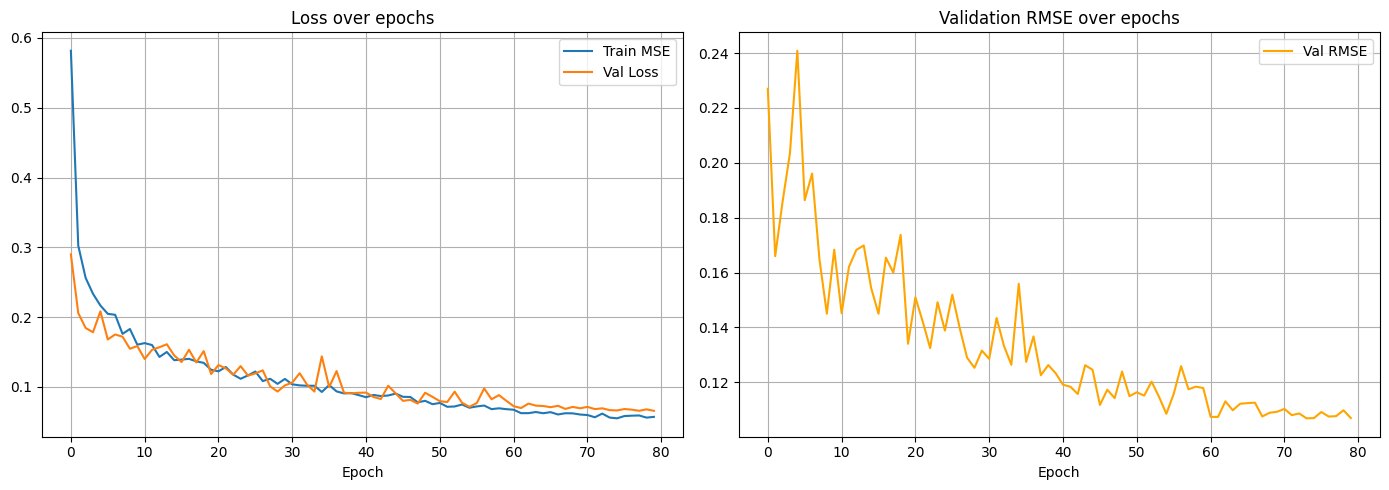

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history["train_loss"], label="Train MSE")
ax1.plot(history["val_loss"],   label="Val Loss")
ax1.set_title("Loss over epochs"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True)

ax2.plot(history["val_rmse"], color="orange", label="Val RMSE")
ax2.set_title("Validation RMSE over epochs"); ax2.set_xlabel("Epoch")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

Evaluating: 100%|██████████| 14/14 [00:00<00:00, 22.16it/s]



── Quality (original scale 0–4.49) ──
  RMSE: 0.5740  (lower is better)
  PLCC: 0.8478  (higher is better, max 1.0)
  SRCC: 0.7824  (higher is better, max 1.0)


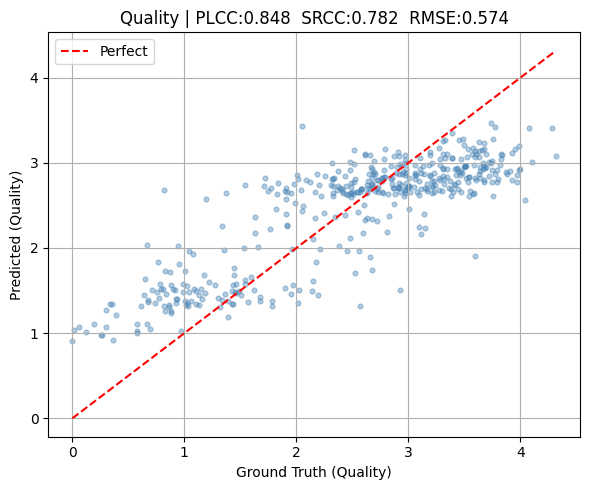

In [8]:
model.eval()
all_preds, all_gt = [], []
with torch.no_grad():
    for images, scores in tqdm(test_loader, desc="Evaluating"):
        preds = model(images.to(DEVICE)).cpu().numpy()
        all_preds.append(preds)
        all_gt.append(scores.numpy())

preds_arr = np.concatenate(all_preds, axis=0)
gt_arr = np.concatenate(all_gt,    axis=0)

# ← TARGET_COLS and NORM_FACTORS from EDA
score_labels = [c.replace("mos_", "").capitalize() for c in TARGET_COLS]

for i, label in enumerate(score_labels):
    # Denormalise back to original scale for interpretable MAE/MSE
    gt_orig = gt_arr[:, i]    * NORM_FACTORS[i]
    pred_orig = preds_arr[:, i] * NORM_FACTORS[i]

    rmse = np.sqrt(mean_squared_error(gt_orig, pred_orig))
    plcc, _ = pearsonr(gt_orig, pred_orig)
    srcc, _ = spearmanr(gt_orig, pred_orig)

    print(f"\n── {label} (original scale 0–{NORM_FACTORS[i]:.2f}) ──")
    print(f"  RMSE: {rmse:.4f}  (lower is better)")
    print(f"  PLCC: {plcc:.4f}  (higher is better, max 1.0)")
    print(f"  SRCC: {srcc:.4f}  (higher is better, max 1.0)")

# Scatter plot
fig, axes = plt.subplots(1, NUM_OUTPUTS, figsize=(6 * NUM_OUTPUTS, 5))
if NUM_OUTPUTS == 1:
    axes = [axes]
for i, (ax, label) in enumerate(zip(axes, score_labels)):
    gt_orig = gt_arr[:, i]    * NORM_FACTORS[i]
    pred_orig = preds_arr[:, i] * NORM_FACTORS[i]
    plcc, _ = pearsonr(gt_orig, pred_orig)
    srcc, _ = spearmanr(gt_orig, pred_orig)
    rmse = np.sqrt(mean_squared_error(gt_orig, pred_orig))
    ax.scatter(gt_orig, pred_orig, alpha=0.4, s=12, color="steelblue")
    mn, mx = gt_orig.min(), gt_orig.max()
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect")
    ax.set_xlabel(f"Ground Truth ({label})")
    ax.set_ylabel(f"Predicted ({label})")
    ax.set_title(f"{label} | PLCC:{plcc:.3f}  SRCC:{srcc:.3f}  RMSE:{rmse:.3f}")
    ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("evaluation_scatter.png")
plt.show()

In [9]:
def predict_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    image  = PILImage.open(img_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(tensor).squeeze().cpu().numpy()

    # ← denormalise back to original scale using EDA NORM_FACTORS
    if NUM_OUTPUTS == 1:
        pred = [pred]
    result = {col: round(float(p) * norm, 4)
              for col, p, norm in zip(TARGET_COLS, pred, NORM_FACTORS)}
    return result

# Example
result = predict_image("data/images/AttnGAN_normal_000.jpg")
print(result)

{'mos_quality': np.float64(1.3723)}
